# Document Field Extraction using LayoutLM (Visual Question Answering)

Extracts structured fields from document images using **visual question answering**.

## Architecture Flow

```mermaid
flowchart TB
    subgraph INPUT["📄 Input"]
        IMG["Image File<br/>(JPG/PNG/BMP)"]
        PDF["PDF Document"]
    end

    subgraph PREPROCESSING["🔧 Preprocessing"]
        LOAD["load_image()"]
        PYMUPDF["PyMuPDF<br/>pdf_page_to_image()"]
        RGB["Convert to RGB<br/>PIL Image"]
    end

    subgraph LAYOUTLM["🤖 LayoutLM Pipeline"]
        subgraph OCR["Tesseract OCR<br/>(automatic)"]
            TEXT["Extract Text"]
            BBOX["Extract Bounding Boxes"]
        end
        MODEL["impira/layoutlm-document-qa<br/>Document Understanding Transformer"]
    end

    subgraph QA["❓ Question Answering"]
        Q1["What is the patient's name?"]
        Q2["What is the doctor's name?"]
        Q3["What is the clinic name?"]
        Q4["What is the certificate ID?"]
        Q5["What is the issue date?"]
    end

    subgraph OUTPUT["📊 Output"]
        FIELDS["Structured Fields<br/>+ Confidence Scores"]
        DF["Pandas DataFrame"]
    end

    IMG --> LOAD
    PDF --> PYMUPDF --> RGB
    LOAD --> RGB
    RGB --> OCR
    TEXT --> MODEL
    BBOX --> MODEL
    MODEL --> Q1 & Q2 & Q3 & Q4 & Q5
    Q1 & Q2 & Q3 & Q4 & Q5 --> FIELDS
    FIELDS --> DF

    style INPUT fill:#e1f5fe
    style PREPROCESSING fill:#fff3e0
    style LAYOUTLM fill:#f3e5f5
    style QA fill:#e8f5e9
    style OUTPUT fill:#fce4ec
```

## Pipeline Summary

| Stage | Component | Description |
|-------|-----------|-------------|
| **1. Input** | `load_image()` | Accepts JPG, PNG, BMP, PDF |
| **2. PDF Handling** | PyMuPDF | Renders PDF page to PIL Image at 200 DPI |
| **3. OCR** | Tesseract | Extracts text + bounding boxes (automatic via HF pipeline) |
| **4. Model** | `impira/layoutlm-document-qa` | Document understanding transformer (~500 MB) |
| **5. QA** | Multi-question strategy | Asks multiple question variants per field |
| **6. Output** | Structured dict | Field values + confidence scores |

### Model: `impira/layoutlm-document-qa`

| Feature | Value |
|---|---|
| Architecture | LayoutLM (Document understanding transformer) |
| Task | Extractive QA over document images |
| Input | Image + natural language question |
| Output | Answer text + confidence score |
| Size | ~500 MB |

**Key difference from OCR + NER approach:**
- **OCR + NER**: Image → Tesseract text → NER model → entity extraction → post-processing
- **LayoutLM QA**: Image → ask question → get answer directly (end-to-end visual understanding)

**Prerequisites:**
- `pip install transformers torch pillow` (LayoutLM pipeline — downloads ~500 MB on first run)
- `pip install pymupdf` (for PDF support)
- `brew install tesseract` (required by the HF pipeline internally)

## Step 0 — Environment Setup

Adds the notebook's parent folder to Python's import path so project modules
can be imported without installing the package.

### Tesseract OCR Requirement

**IMPORTANT:** The `impira/layoutlm-document-qa` model requires **Tesseract OCR** to be
installed. LayoutLM is a multimodal model that needs OCR text + bounding boxes as input —
the Hugging Face pipeline extracts these automatically using Tesseract.

**Install Tesseract:**
```bash
# macOS
brew install tesseract

# Ubuntu/Debian
sudo apt-get install tesseract-ocr

# Windows
# Download installer from: https://github.com/UB-Mannheim/tesseract/wiki
```

The code cell below adds `/opt/homebrew/bin` (Homebrew's default location on Apple Silicon)
to `$PATH` so the pipeline can find Tesseract.

In [1]:
# Make the project root importable.
import os
import sys
from pathlib import Path

# ── Fix Tesseract PATH ─────────────────────────────────────────────────────────
# The LayoutLM pipeline uses pytesseract internally, which looks for the
# `tesseract` binary in $PATH. On macOS with Homebrew, it's at /opt/homebrew/bin.
# Adding this to PATH before importing transformers ensures the pipeline finds it.
TESSERACT_PATH = "/opt/homebrew/bin"
if TESSERACT_PATH not in os.environ.get("PATH", ""):
    os.environ["PATH"] = TESSERACT_PATH + ":" + os.environ.get("PATH", "")
    print(f"Added {TESSERACT_PATH} to PATH for Tesseract OCR")

# Verify Tesseract is now accessible.
import shutil
tesseract_bin = shutil.which("tesseract")
if tesseract_bin:
    print(f"Tesseract found: {tesseract_bin}")
else:
    print("WARNING: Tesseract not found! Install with: brew install tesseract")
# ───────────────────────────────────────────────────────────────────────────────

# Notebook lives in <root>/Hugging face model/impira ---- layoutlm-document-qa/,
# so we go up two levels to reach the workspace root.
PROJECT_ROOT = Path.cwd().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Added /opt/homebrew/bin to PATH for Tesseract OCR
Tesseract found: /opt/homebrew/bin/tesseract
Project root: /Users/I578366/Desktop/My Workspace/NLP-NER-Text-Processing


## Configuration & Image Discovery

Defines **which images the notebook will process** and **which one to inspect**
in the single-image cells below.

| Variable | Meaning |
|---|---|
| `IMAGE_FOLDER` | Folder scanned for input images |
| `INSPECT_INDEX` | Index into the sorted file list — controls single-image inspection |
| `EXTENSIONS`   | File suffixes accepted (case-insensitive) |

The cell enumerates the folder, filters by extension, sorts the results, and
prints the list with an arrow marker (`← inspect`) next to whichever file will
be used for single-image inspection.

In [2]:
# ── Configuration ──────────────────────────────────────────────────────────────
# Root folder scanned recursively — every image/PDF in any subfolder is picked up.
IMAGE_FOLDER = Path.cwd().parent.parent / "test_data" / "sick_notes"

# Which image to use for the single-image inspection cells below.
INSPECT_INDEX = 0

# Supported extensions.
EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif", ".pdf"}
# ───────────────────────────────────────────────────────────────────────────────

if not IMAGE_FOLDER.exists():
    raise FileNotFoundError(f"Folder not found: {IMAGE_FOLDER}")

image_paths = sorted(
    p for p in IMAGE_FOLDER.rglob("*")
    if p.is_file() and p.suffix.lower() in EXTENSIONS
)

if not image_paths:
    raise FileNotFoundError(f"No images found under {IMAGE_FOLDER}")

print(f"Found {len(image_paths)} file(s) under {IMAGE_FOLDER}:")
for i, p in enumerate(image_paths):
    marker = " ← inspect" if i == INSPECT_INDEX else ""
    rel = p.relative_to(IMAGE_FOLDER)
    print(f"  [{i}] {rel}{marker}")

Found 23 file(s) under /Users/I578366/Desktop/My Workspace/NLP-NER-Text-Processing/test_data/sick_notes:
  [0] Test data/Sick_Note_1.jpg ← inspect
  [1] Test data/Sick_note_2.jpg
  [2] Test data/Sick_note_8.pdf
  [3] Test data/sick_note_10.jpg
  [4] Test data/sick_note_12.pdf
  [5] Test data/sick_note_13.jpg
  [6] Test data/sick_note_14.pdf
  [7] Test data/sick_note_15.jpg
  [8] Test data/sick_note_17.pdf
  [9] Test data/sick_note_18.pdf
  [10] Test data/sick_note_19.png
  [11] Test data/sick_note_20.pdf
  [12] Test data/sick_note_21.pdf
  [13] Test data/sick_note_3.jpg
  [14] Test data/sick_note_9.jpg
  [15] authentic/SickNote_AI_jpg1.jpg
  [16] fake/AI_c2pa_image_2.png
  [17] suspicious/Sick_Note_1.jpg
  [18] suspicious/Sick_note_No_Seal.png
  [19] suspicious/date_mismatch.png
  [20] suspicious/negative_no_seal_001.png
  [21] suspicious/sicknote_1.jpg
  [22] suspicious/sicknote_1.png


## Step 1 — Helper Functions

### PDF → Image Helper

Renders a single PDF page to a PIL `Image` using **PyMuPDF (`fitz`)** so the
pipeline can treat PDFs and raster images uniformly.

- `dpi=200` upscales the render enough for reliable document reading.
- `alpha=False` produces an opaque RGB pixmap (no transparency channel).
- Renders only the requested page (`page_index=0` by default).

### Image Loading Helper

`load_image(path)` handles both image files and PDFs, returning a PIL Image
ready for the LayoutLM pipeline.

In [3]:
import fitz  # PyMuPDF
from PIL import Image


def pdf_page_to_image(pdf_path: Path, page_index: int = 0, dpi: int = 200) -> Image.Image:
    """Render one PDF page to a PIL Image at the given DPI."""
    doc = fitz.open(str(pdf_path))
    page = doc[page_index]
    mat = fitz.Matrix(dpi / 72, dpi / 72)
    pix = page.get_pixmap(matrix=mat, alpha=False)
    return Image.frombytes("RGB", (pix.width, pix.height), pix.samples)


def load_image(path: Path) -> Image.Image:
    """Load an image from file — supports both raster images and PDFs."""
    if path.suffix.lower() == ".pdf":
        return pdf_page_to_image(path)
    img = Image.open(path)
    # Convert to RGB if needed (handles RGBA, grayscale, etc.)
    if img.mode != "RGB":
        img = img.convert("RGB")
    return img


print("Helper functions loaded.")

Helper functions loaded.


## Step 2 — LayoutLM Document QA Model Setup

Loads the `impira/layoutlm-document-qa` model once and reuses it for all images.

### Model Details

| Property | Value |
|---|---|
| Model ID | `impira/layoutlm-document-qa` |
| Pipeline type | `document-question-answering` |
| Input | PIL Image + question string |
| Output | `{"answer": str, "score": float, "start": int, "end": int}` |

### Lazy Singleton Pattern

The model is ~500 MB and takes 30–60 seconds to load. To avoid paying that
cost more than once per session, the pipeline is stored in a module-level
variable and returned on subsequent calls:

```python
_qa_pipeline: object = None  # cache slot

def _get_qa_pipeline() -> object:
    global _qa_pipeline
    if _qa_pipeline is None:  # first call → build
        _qa_pipeline = pipeline("document-question-answering", model=MODEL_ID)
    return _qa_pipeline       # subsequent calls → reuse
```

### Model Cache Location

On first call, the model is automatically downloaded and cached by Hugging Face:

- **macOS/Linux**: `~/.cache/huggingface/hub/`
- **Windows**: `C:\Users\<username>\.cache\huggingface\hub\`

In [4]:
from transformers import pipeline

# Model ID — LayoutLM fine-tuned for document question answering.
_MODEL_ID = "impira/layoutlm-document-qa"
_qa_pipeline: object = None  # lazy-loaded on first call


def _get_qa_pipeline() -> object:
    """Return the document QA pipeline, loading it on first call."""
    global _qa_pipeline
    if _qa_pipeline is None:
        print(f"Loading LayoutLM model ({_MODEL_ID}) — first call only, ~30–60 sec ...")
        _qa_pipeline = pipeline(
            "document-question-answering",
            model=_MODEL_ID,
        )
        print("LayoutLM model ready.")
    return _qa_pipeline


# Reset the pipeline to force reload with the new PATH.
_qa_pipeline = None
print(f"QA loader defined — model will reload on next extract_fields_qa() call.")

/Users/I578366/Desktop/My Workspace/NLP-NER-Text-Processing/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


QA loader defined — model will reload on next extract_fields_qa() call.


## Step 3 — Field Extraction via Question Answering

The **core extractor**. Asks targeted questions about the document image and
collects the model's answers into a structured dictionary.

### Questions per Field

| Field | Question(s) |
|---|---|
| `patient_name` | "What is the patient's name?" |
| `doctor_name` | "What is the doctor's name?" |
| `clinic_name` | "What is the clinic or hospital name?" |
| `certificate_id` | "What is the certificate ID or document number?" |
| `issue_date` | "What is the issue date?" or "What is the date?" |

### Output Format

```python
{
    "patient_name": "John Smith",
    "patient_name_confidence": 0.95,
    "doctor_name": "Dr. Anna Müller",
    "doctor_name_confidence": 0.88,
    ...
}
```

Each field includes a `_confidence` suffix with the model's score (0.0–1.0).

### Confidence Threshold

Answers with confidence below `MIN_CONFIDENCE` (default 0.1) are discarded as
unreliable — the model sometimes hallucinates low-confidence garbage when the
answer isn't present in the document.

In [5]:
from typing import Any

# Minimum confidence threshold — answers below this are discarded.
MIN_CONFIDENCE = 0.1

# Questions to ask for each field.
# Some fields have multiple question variants to improve extraction accuracy.
_FIELD_QUESTIONS = {
    "patient_name": [
        "What is the patient's name?",
        "What is the name of the patient?",
    ],
    "doctor_name": [
        "What is the doctor's name?",
        "Who is the attending physician?",
    ],
    "clinic_name": [
        "What is the clinic or hospital name?",
        "What is the name of the medical facility?",
    ],
    "certificate_id": [
        "What is the certificate ID or document number?",
        "What is the reference number?",
    ],
    "issue_date": [
        "What is the issue date?",
        "What is the date of issue?",
        "What is the date?",
    ],
}


def _ask_question(image: Image.Image, question: str) -> dict[str, Any]:
    """Ask a single question about the document image.
    
    Returns: {"answer": str, "score": float} or {"answer": None, "score": 0.0}
    """
    qa = _get_qa_pipeline()
    try:
        # The pipeline returns a list of answers; take the top one.
        results = qa(image, question)
        if results and isinstance(results, list) and len(results) > 0:
            top = results[0]
            return {
                "answer": top.get("answer", "").strip(),
                "score": float(top.get("score", 0.0)),
            }
    except Exception as e:  # noqa: BLE001
        print(f"  Warning: QA failed for '{question}': {e}")
    return {"answer": None, "score": 0.0}


def extract_fields_qa(image: Image.Image) -> dict[str, Any]:
    """Extract structured fields from a document image using QA.
    
    For each field, tries multiple question variants and keeps the
    highest-confidence answer above MIN_CONFIDENCE.
    
    Returns a dict with field values and their confidence scores.
    """
    fields: dict[str, Any] = {}
    
    for field_name, questions in _FIELD_QUESTIONS.items():
        best_answer: str | None = None
        best_score: float = 0.0
        
        # Try each question variant and keep the best answer.
        for question in questions:
            result = _ask_question(image, question)
            answer = result["answer"]
            score = result["score"]
            
            # Keep this answer if it's better than what we have.
            if answer and score > best_score:
                best_answer = answer
                best_score = score
        
        # Only include if confidence is above threshold.
        if best_score >= MIN_CONFIDENCE:
            fields[field_name] = best_answer
            fields[f"{field_name}_confidence"] = round(best_score, 4)
        else:
            fields[field_name] = None
            fields[f"{field_name}_confidence"] = 0.0
    
    return fields


print("Field extraction function loaded.")
print(f"Fields to extract: {list(_FIELD_QUESTIONS.keys())}")
print(f"Minimum confidence threshold: {MIN_CONFIDENCE}")

Field extraction function loaded.
Fields to extract: ['patient_name', 'doctor_name', 'clinic_name', 'certificate_id', 'issue_date']
Minimum confidence threshold: 0.1


## Step 4 — Inspect a Single Image

Runs the **full pipeline on just one image** so you can verify extraction
quality before committing to a full batch run.

The image used is `image_paths[INSPECT_INDEX]` — change `INSPECT_INDEX` in the
config cell to pick a different file.

**Sub-steps:**
1. Load the image (this cell — displays it inline for visual reference).
2. Run field extraction and print results with confidence scores.

[0] Sick_Note_1.jpg
Size: (563, 729)  Mode: RGB



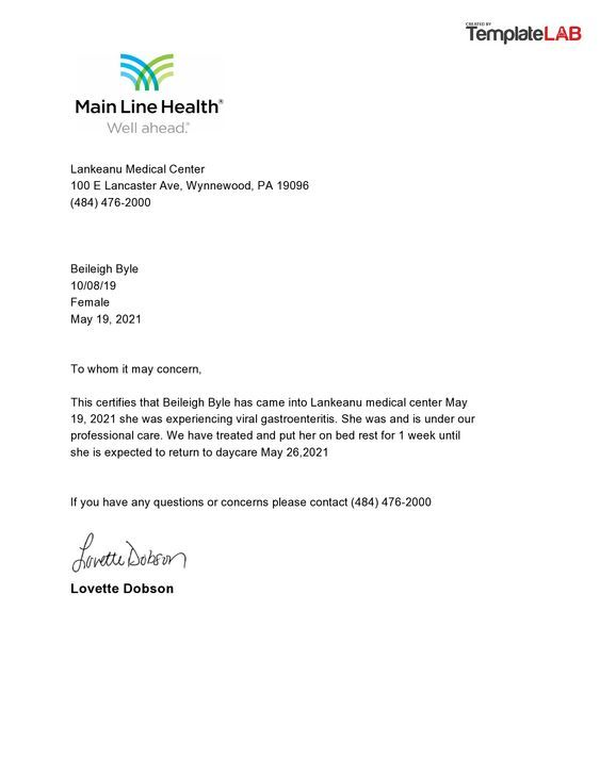

In [6]:
# Load and display the inspection image.
inspect_path = image_paths[INSPECT_INDEX]
inspect_image = load_image(inspect_path)

print(f"[{INSPECT_INDEX}] {inspect_path.name}")
print(f"Size: {inspect_image.size}  Mode: {inspect_image.mode}")
print()

# Display the image (scaled down for notebook viewing).
display_width = 600
ratio = display_width / inspect_image.width
display_size = (display_width, int(inspect_image.height * ratio))
inspect_image.resize(display_size, Image.LANCZOS)

### Extract Fields from Inspection Image

Runs `extract_fields_qa()` on the loaded image and prints each field with its
extracted value and confidence score.

**Interpreting confidence scores:**
- **> 0.9** — Very confident, likely correct
- **0.5 – 0.9** — Moderately confident, verify manually
- **< 0.5** — Low confidence, may be incorrect or hallucinated
- **0.0** — Field not found (below minimum threshold)

In [7]:
print(f"Extracting fields from: {inspect_path.name}")
print("=" * 60)

inspect_fields = extract_fields_qa(inspect_image)

print("\n=== Extracted Fields ===")
for field_name in _FIELD_QUESTIONS.keys():
    value = inspect_fields.get(field_name)
    confidence = inspect_fields.get(f"{field_name}_confidence", 0.0)
    
    # Confidence indicator.
    if confidence >= 0.9:
        indicator = "✓✓"
    elif confidence >= 0.5:
        indicator = "✓"
    elif confidence > 0:
        indicator = "?"
    else:
        indicator = "✗"
    
    print(f"{indicator} {field_name:20s}: {value or '(not found)':30s}  [conf: {confidence:.2%}]")

Extracting fields from: Sick_Note_1.jpg
Loading LayoutLM model (impira/layoutlm-document-qa) — first call only, ~30–60 sec ...


Loading weights: 100%|██████████| 205/205 [00:00<00:00, 9507.53it/s]


LayoutLM model ready.

=== Extracted Fields ===
✓✓ patient_name        : Lovette Dobson                  [conf: 93.17%]
✓✓ doctor_name         : Lovette Dobson                  [conf: 99.88%]
✓✓ clinic_name         : Lankeanu Medical Center         [conf: 99.99%]
? certificate_id      : (484) 476-2000                  [conf: 17.50%]
✓✓ issue_date          : May 19, 2021                    [conf: 99.95%]


## Step 5 — Batch Processing

Runs the full pipeline on **every image in `IMAGE_FOLDER`** and collects the
results into a list of dicts (which the next cell turns into a DataFrame).

For each file:
1. Load image — `pdf_page_to_image()` for `.pdf`, otherwise `Image.open()`.
2. `extract_fields_qa()` → structured dictionary with confidence scores.
3. Append a merged row: `{file, **fields}`.

The `except Exception` around each iteration is intentional — the batch loop
must keep going even if a single image fails, and the failure row records the
error string so you can spot it in the DataFrame.

In [8]:
results = []

for i, path in enumerate(image_paths):
    print(f"[{i+1}/{len(image_paths)}] Processing {path.name} ...", end=" ", flush=True)
    try:
        img = load_image(path)
        fields = extract_fields_qa(img)
        
        results.append({
            "file": path.name,
            "subfolder": path.parent.name,
            **fields,
        })
        
        # Show quick summary.
        patient = fields.get("patient_name") or "—"
        date = fields.get("issue_date") or "—"
        print(f"OK  (patient: {patient}, date: {date})")
        
    except Exception as exc:  # noqa: BLE001
        print(f"FAILED — {exc}")
        results.append({"file": path.name, "subfolder": path.parent.name, "error": str(exc)})

print(f"\nDone. {len(results)} image(s) processed.")

[1/23] Processing Sick_Note_1.jpg ... OK  (patient: Lovette Dobson, date: May 19, 2021)
[2/23] Processing Sick_note_2.jpg ... OK  (patient: T’Erika Harley, date: January 29, 2022)
[3/23] Processing Sick_note_8.pdf ... OK  (patient: Gastroenterology Specialist, date: (325) 880-4213)
[4/23] Processing sick_note_10.jpg ... OK  (patient: Florida Hospital Urgent Care:, date: (9/27/2047)
[5/23] Processing sick_note_12.pdf ... OK  (patient: Rafael Ilyayev,, date: Monday June 28th, 2021)
[6/23] Processing sick_note_13.jpg ... OK  (patient: Dr. Waters, date: 11/13/2017)
[7/23] Processing sick_note_14.pdf ... OK  (patient: Nelly Darwin, date: September 17, 2025)
[8/23] Processing sick_note_15.jpg ... OK  (patient: Nelly Darwin, date: September 17, 2025)
[9/23] Processing sick_note_17.pdf ... OK  (patient: Emily Johnson,, date: August 3, 2026)
[10/23] Processing sick_note_18.pdf ... OK  (patient: Emily Thompson,, date: 25 September 2025)
[11/23] Processing sick_note_19.png ... OK  (patient: Dr.Sa

### Results as a Pandas DataFrame

Builds a `pandas.DataFrame` with a human-friendly column order:

- **Priority columns first** — `file`, `subfolder`, then the main extracted fields.
- **Confidence columns** — grouped after each field.
- **Error column** — at the end (only present for failed rows).

The DataFrame provides a quick overview of extraction quality across all images.

In [9]:
import pandas as pd
import json

# Print raw JSON for full inspection.
print("=== Raw Results (JSON) ===")
print(json.dumps(results, indent=2, default=str))

# Build DataFrame.
df = pd.DataFrame(results)

# Define column order.
priority_cols = [
    "file", "subfolder",
    "patient_name", "patient_name_confidence",
    "doctor_name", "doctor_name_confidence",
    "clinic_name", "clinic_name_confidence",
    "certificate_id", "certificate_id_confidence",
    "issue_date", "issue_date_confidence",
]
ordered_cols = [c for c in priority_cols if c in df.columns] + \
               [c for c in df.columns if c not in priority_cols]

# Display settings.
pd.set_option("display.max_colwidth", 40)
pd.set_option("display.max_columns", 20)

print("\n=== Results DataFrame ===")
df[ordered_cols]

=== Raw Results (JSON) ===
[
  {
    "file": "Sick_Note_1.jpg",
    "subfolder": "Test data",
    "patient_name": "Lovette Dobson",
    "patient_name_confidence": 0.9317,
    "doctor_name": "Lovette Dobson",
    "doctor_name_confidence": 0.9988,
    "clinic_name": "Lankeanu Medical Center",
    "clinic_name_confidence": 0.9999,
    "certificate_id": "(484) 476-2000",
    "certificate_id_confidence": 0.175,
    "issue_date": "May 19, 2021",
    "issue_date_confidence": 0.9995
  },
  {
    "file": "Sick_note_2.jpg",
    "subfolder": "Test data",
    "patient_name": "T\u2019Erika Harley",
    "patient_name_confidence": 1.0,
    "doctor_name": "Jennifer A. Greene",
    "doctor_name_confidence": 0.8004,
    "clinic_name": "LEXINGTON MEDICAL CENTER",
    "clinic_name_confidence": 0.9998,
    "certificate_id": "(803)-791-2000",
    "certificate_id_confidence": 0.8649,
    "issue_date": "January 29, 2022",
    "issue_date_confidence": 1.0
  },
  {
    "file": "Sick_note_8.pdf",
    "subfolder"

,file,subfolder,patient_name,patient_name_confidence,doctor_name,doctor_name_confidence,clinic_name,clinic_name_confidence,certificate_id,certificate_id_confidence,issue_date,issue_date_confidence
0,Sick_Note_1.jpg,Test data,Lovette Dobson,0.9317,Lovette Dobson,0.9988,Lankeanu Medical Center,0.9999,(484) 476-2000,0.1750,"May 19, 2021",0.9995
1,Sick_note_2.jpg,Test data,T’Erika Harley,1.0000,Jennifer A. Greene,0.8004,LEXINGTON MEDICAL CENTER,0.9998,(803)-791-2000,0.8649,"January 29, 2022",1.0000
2,Sick_note_8.pdf,Test data,Gastroenterology Specialist,0.9971,Gastroenterology Specialist,0.9984,contact@stheliosmed.org,0.4068,(325) 880-4213,0.9798,(325) 880-4213,0.1058
3,sick_note_10.jpg,Test data,Florida Hospital Urgent Care:,0.3029,Florida Hospital,0.6931,FLORIDA un us nen HOSPITAL,0.9997,065438,0.9744,(9/27/2047,0.9990
4,sick_note_12.pdf,Test data,"Rafael Ilyayev,",0.9920,"Rafael Ilyayev,",0.9996,Refua Shlema Medical PC,0.9998,NaN,0.0000,"Monday June 28th, 2021",0.9996
5,sick_note_13.jpg,Test data,Dr. Waters,0.9997,Dr. Waters,0.9999,NaN,0.0000,TemplateLAB,0.9589,11/13/2017,0.9999
6,sick_note_14.pdf,Test data,Nelly Darwin,0.9998,DR. RILEY SNIPES,0.9996,Central Hospital,1.0000,"September 17, 2025",0.8452,"September 17, 2025",0.9985
7,sick_note_15.jpg,Test data,Nelly Darwin,0.9999,Nelly Darwin,0.9952,Central Hospital,1.0000,"September 17, 2025",0.9226,"September 17, 2025",1.0000
8,sick_note_17.pdf,Test data,"Emily Johnson,",0.9997,"Dr. Sarah Mitchell,",0.9933,Northside Family Medical Clinic,0.9997,(555) 123-4567,0.9994,"August 3, 2026",0.9999
9,sick_note_18.pdf,Test data,"Emily Thompson,",0.9998,"Dr. Jessica Monroe,",0.9938,jmonroe@crestlinedental.com,0.5269,jmonroe@crestlinedental.com,0.9860,25 September 2025,1.0000


## Step 6 — Summary Statistics

Quick overview of extraction success rates and average confidence scores
across all processed images.

In [10]:
print("=== Extraction Summary ===")
print(f"Total images processed: {len(results)}")
print()

# Count successful extractions per field.
for field_name in _FIELD_QUESTIONS.keys():
    # Count non-None values.
    extracted = sum(1 for r in results if r.get(field_name) is not None)
    pct = (extracted / len(results)) * 100 if results else 0
    
    # Average confidence for extracted values.
    conf_key = f"{field_name}_confidence"
    confidences = [r.get(conf_key, 0) for r in results if r.get(field_name) is not None]
    avg_conf = sum(confidences) / len(confidences) if confidences else 0
    
    print(f"{field_name:20s}: {extracted:2d}/{len(results)} extracted ({pct:5.1f}%)  avg confidence: {avg_conf:.2%}")

# Count errors.
errors = sum(1 for r in results if "error" in r)
if errors:
    print(f"\nErrors: {errors} image(s) failed to process")

=== Extraction Summary ===
Total images processed: 23

patient_name        : 23/23 extracted (100.0%)  avg confidence: 95.76%
doctor_name         : 23/23 extracted (100.0%)  avg confidence: 97.39%
clinic_name         : 20/23 extracted ( 87.0%)  avg confidence: 89.57%
certificate_id      : 22/23 extracted ( 95.7%)  avg confidence: 83.30%
issue_date          : 22/23 extracted ( 95.7%)  avg confidence: 91.33%


## Appendix — Custom Question Testing

Use this cell to test custom questions on the inspection image. Helpful for
debugging extraction or trying alternative phrasings.

In [11]:
# Test custom questions on the inspection image.
custom_questions = [
    "What is the patient's name?",
    "What is the diagnosis?",
    "What is the sick leave period?",
    "From when to when is the sick leave?",
]

print(f"Testing custom questions on: {inspect_path.name}")
print("=" * 60)

for question in custom_questions:
    result = _ask_question(inspect_image, question)
    answer = result["answer"] or "(no answer)"
    score = result["score"]
    print(f"\nQ: {question}")
    print(f"A: {answer}  [confidence: {score:.2%}]")

Testing custom questions on: Sick_Note_1.jpg

Q: What is the patient's name?
A: Beileigh Byle  [confidence: 84.30%]

Q: What is the diagnosis?
A: viral gastroenteritis.  [confidence: 82.74%]

Q: What is the sick leave period?
A: May 19, 2021  [confidence: 0.17%]

Q: From when to when is the sick leave?
A: May 19, 2021  [confidence: 0.28%]
